In [1]:
import brainpy as bp
import brainpy.math as bm
import numpy as np
import matplotlib.pyplot as plt

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
V_L = -70 # mV. The resting threshold
g_L = 16.7 # ns. The leak conductance
dg_k = 10. # nS. The unit increase in potassium current
C = 0.25 # nF. The capacitance, sometimes written as tau_m. Seems much lower than the default value?

Predict 100 steps: : 100%|██████████| 100/100 [00:00<00:00, 1090.93it/s]


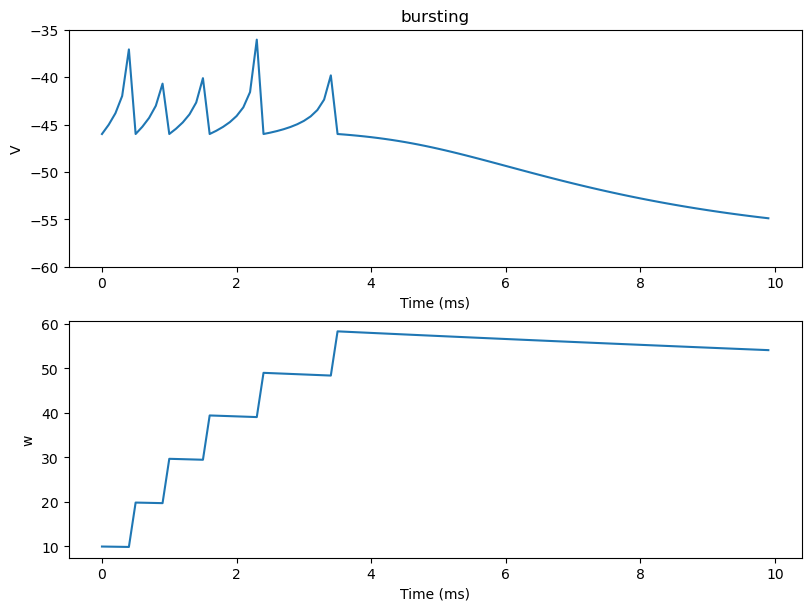

In [5]:
group = bp.neurons.AdExIF(size=1, a=-0.5, b=dg_k, R=1., delta_T=2., tau=5, tau_w=100,
                          V_reset=-46, V_rest=-70, V_th=-30, V_T=-50)

runner = bp.DSRunner(group, monitors=['V', 'w'], inputs=('input', 65.))
runner.run(10.)
fig, gs = bp.visualize.get_figure(2, 1, 3, 8)
fig.add_subplot(gs[0, 0])
bp.visualize.line_plot(runner.mon.ts, runner.mon.V, ylabel='V', ylim=(-60., -35.), title='bursting')
fig.add_subplot(gs[1, 0])
bp.visualize.line_plot(runner.mon.ts, runner.mon.w, ylabel='w', show=True)